In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, PowerNorm
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.patheffects as path_effects
import os
import sys
from scipy import stats
from sunpy.coordinates import frames
import sunpy.map
from sunpy.net import Fido
from sunpy.net import attrs as a

In [2]:
import pickle
with open('fig1_data.pkl', 'rb') as f:
    loaded_fig1_data = pickle.load(f)

nlfff_data = loaded_fig1_data['panel1_data']['reference_field']
pred_data = loaded_fig1_data['panel1_data']['generated_field']
PF_data = loaded_fig1_data['panel1_data']['potential_field']
retd_data = loaded_fig1_data['panel1_data']['retrained_field']
J_ref = loaded_fig1_data['panel2_data']['J_ref']
J_gen = loaded_fig1_data['panel2_data']['J_gen']
J_ret = loaded_fig1_data['panel2_data']['J_ret']
PE_ref = loaded_fig1_data['panel2_data']['PE_ref']
PE_gen = loaded_fig1_data['panel2_data']['PE_gen']
PE_ret = loaded_fig1_data['panel2_data']['PE_ret']
fi_ref_list = loaded_fig1_data['panel3_data']['fi_ref_list']
fi_gen_list = loaded_fig1_data['panel3_data']['fi_gen_list']
sj_ref_list = loaded_fig1_data['panel3_data']['sj_ref_list']
sj_gen_list = loaded_fig1_data['panel3_data']['sj_gen_list']

/tmp/ipykernel_717251/1735743602.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  aia_304_cmap = plt.cm.get_cmap('sdoaia304')


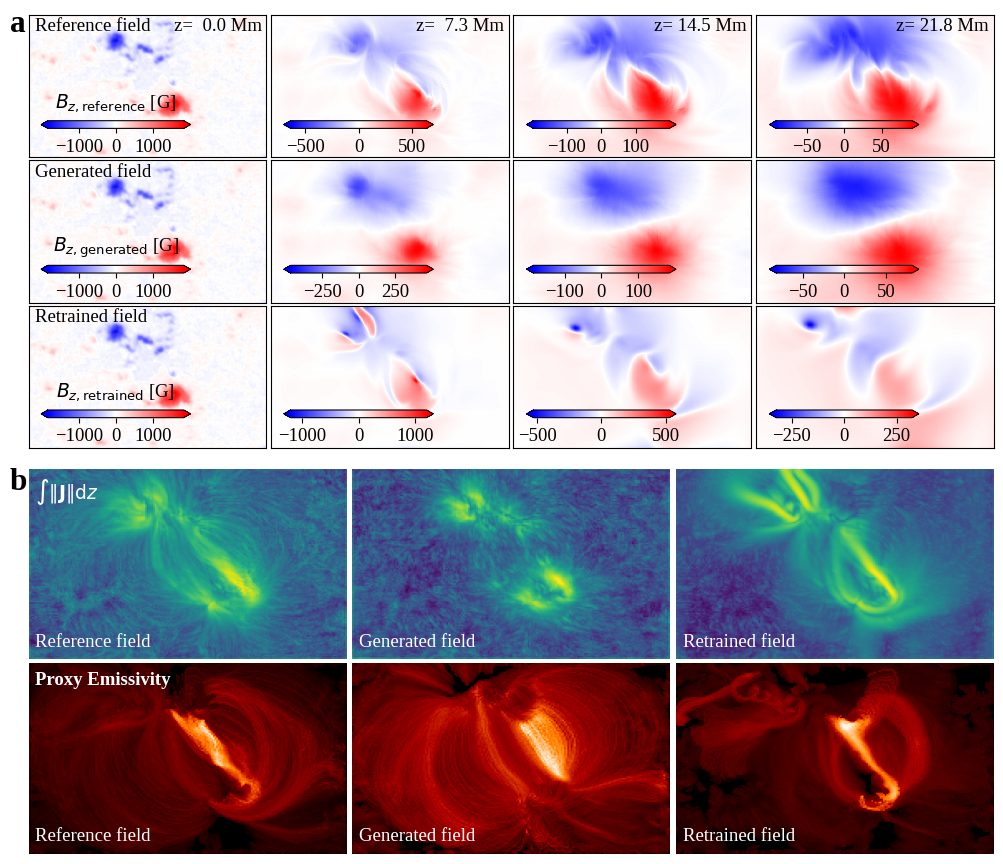

In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import numpy as np
from PIL import Image
from scipy import stats



# 设置参数
zoom_factor = 1.5
plt.rcParams['font.size'] = 9.0 * zoom_factor
plt.rcParams['font.family'] = 'Liberation Serif'
A4_width = 8.3 * zoom_factor
A4_length = 11.7 * zoom_factor
golden_ratio = 0.618
plot_height = A4_width*(golden_ratio*3/4+golden_ratio*2/3)
aia_304_cmap = plt.cm.get_cmap('sdoaia304')

# 创建大图
fig = plt.figure(figsize=(A4_width, plot_height))

# 创建 GridSpec
gs = gridspec.GridSpec(2, 1, height_ratios=[golden_ratio*3/4, golden_ratio*2/3])

### 第一个 panel ###
gs0 = gridspec.GridSpecFromSubplotSpec(3, 4, subplot_spec=gs[0], wspace=0.02, hspace=0.02)

idir = 2
dx = 0.195
dy = 0.188
cbar_x0 = 0.135
cbar_y0 = 0.78
cbar_w  = 0.12
cbar_h  = 0.01
cbar_y0 = cbar_y0*(golden_ratio/plot_height*A4_width)+1-golden_ratio*A4_width/plot_height-0.069
cbar_h  = cbar_h*(golden_ratio/plot_height*A4_width)
dy      = dy*(golden_ratio/plot_height*A4_width)
first = True
cmap = 'bwr'
max_zlevel = 30

for i in range(4):
    ax = fig.add_subplot(gs0[i])
    im = ax.imshow(nlfff_data[idir, :, :, i * max_zlevel // 3], cmap=cmap, aspect='auto', zorder=-1)
    ax.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
    clim_value = max(nlfff_data[idir, :, :, i * max_zlevel // 3].max(), np.abs(nlfff_data[idir, :, :, i * max_zlevel // 3].min()))
    im.set_clim(-clim_value, clim_value)
    ax.text(0.98, 0.98, f'z={(i * max_zlevel // 3 * 0.726):5.1f} Mm', transform=ax.transAxes, ha='right', va='top', fontsize=9.0 * zoom_factor)
    cbaxes = fig.add_axes([cbar_x0 + i * dx, cbar_y0, cbar_w, cbar_h])
    cbaxes.xaxis.set_ticks_position('top')
    cbar = plt.colorbar(im, cax=cbaxes, orientation='horizontal', extend='both')
    cbar.outline.set_edgecolor('black')
    cbar.ax.tick_params(axis='x', colors='black')
    cbar.ax.xaxis.set_label_position('top')
    if first:
        cbar.set_label('$B_{z,\mathrm{reference}}$ [G]', labelpad=10)
        first = False
        ax.text(0.025,0.98,'Reference field',transform=ax.transAxes, ha='left', va='top', fontsize=9.0 * zoom_factor)

# 第二行的图
first = True
for i in range(5, 9):
    ax = fig.add_subplot(gs0[i-1])
    im = ax.imshow(pred_data[idir, :, :, (i - 5) * max_zlevel // 3], cmap=cmap, aspect='auto', zorder=-1)
    ax.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
    clim_value = max(pred_data[idir, :, :, (i - 5) * max_zlevel // 3].max(), np.abs(pred_data[idir, :, :, (i - 5) * max_zlevel // 3].min()))
    im.set_clim(-clim_value, clim_value)
    cbaxes = fig.add_axes([cbar_x0 + (i - 5) * dx, cbar_y0 - dy, cbar_w, cbar_h])
    cbaxes.xaxis.set_ticks_position('top')
    cbar = plt.colorbar(im, cax=cbaxes, orientation='horizontal', extend='both')
    cbar.outline.set_edgecolor('black')
    cbar.ax.tick_params(axis='x', colors='black')
    cbar.ax.xaxis.set_label_position('top')
    if first:
        cbar.set_label(r'$B_{z,\mathrm{generated}}$ [G]', labelpad=10)
        first = False
        ax.text(0.025,0.98,'Generated field',transform=ax.transAxes, ha='left', va='top', fontsize=9.0 * zoom_factor)

# 第三行的图
first = True
for i in range(9, 13):
    ax = fig.add_subplot(gs0[i-1])
    im = ax.imshow(retd_data[idir, :, :, (i - 9) * max_zlevel // 3], cmap=cmap, aspect='auto', zorder=-1)
    ax.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
    clim_value = max(retd_data[idir, :, :, (i - 9) * max_zlevel // 3].max(), np.abs(retd_data[idir, :, :, (i - 9) * max_zlevel // 3].min()))
    im.set_clim(-clim_value, clim_value)
    cbaxes = fig.add_axes([cbar_x0 + (i - 9) * dx, cbar_y0 - dy*2, cbar_w, cbar_h])
    cbaxes.xaxis.set_ticks_position('top')
    cbar = plt.colorbar(im, cax=cbaxes, orientation='horizontal', extend='both')
    cbar.outline.set_edgecolor('black')
    cbar.ax.tick_params(axis='x', colors='black')
    cbar.ax.xaxis.set_label_position('top')
    if first:
        cbar.set_label(r'$B_{z,\mathrm{retrained}}$ [G]', labelpad=10)
        first = False
        ax.text(0.025,0.98,'Retrained field',transform=ax.transAxes, ha='left', va='top', fontsize=9.0 * zoom_factor)

### 第二个 panel ###
gs1 = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=gs[1], wspace=0.02, hspace=0.02)

# 图片和注释
ax1 = fig.add_subplot(gs1[0])
ax1.imshow(J_ref, aspect='auto', norm=matplotlib.colors.LogNorm())
ax1.axis('off')
ax1.text(0.02,0.96, r'$\int\Vert\mathbf{J}\Vert\mathrm{d}z$', transform=plt.gca().transAxes,ha='left',va='top',fontsize=9.0*zoom_factor, color='white')
ax1.text(0.02,0.05, 'Reference field', transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='white')


ax2 = fig.add_subplot(gs1[1])
ax2.imshow(J_gen,aspect='auto',norm=matplotlib.colors.LogNorm())
ax2.text(0.02,0.05, 'Generated field', transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='white')
ax2.axis('off')

# Emissivity data
ax3 = fig.add_subplot(gs1[2])
ax3.imshow(J_ret,aspect='auto',norm=matplotlib.colors.LogNorm())
ax3.text(0.02,0.05, 'Retrained field', transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='white')
ax3.axis('off')

ax4 = fig.add_subplot(gs1[3])
ax4.imshow(PE_ref,aspect='auto',norm=matplotlib.colors.PowerNorm(0.3),cmap=aia_304_cmap)
ax4.text(0.02,0.96, 'Proxy Emissivity', transform=plt.gca().transAxes,ha='left',va='top',fontsize=9.0*zoom_factor, color='white', fontweight='bold')
ax4.text(0.02,0.05, 'Reference field', transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='white')
ax4.axis('off')

ax5 = fig.add_subplot(gs1[4])
ax5.imshow(PE_gen,aspect='auto',norm=matplotlib.colors.PowerNorm(0.3),cmap=aia_304_cmap)
ax5.text(0.02,0.05, 'Generated field', transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='white')
ax5.axis('off')

ax6 = fig.add_subplot(gs1[5])
ax6.imshow(PE_ret,aspect='auto',norm=matplotlib.colors.PowerNorm(0.20),cmap=aia_304_cmap)
ax6.text(0.02,0.05, 'Retrained field', transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='white')
ax6.axis('off')

# ### 第三个 panel ###
# gs2 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[2], wspace=0.1, hspace=0.02)

# ax7 = fig.add_subplot(gs2[0])
# bins = np.arange(-3.5,-2.0,0.02)
# ax7.hist(np.log10(fi_ref_list), bins=bins, alpha=0.8, label='Reference data')
# ax7.hist(np.log10(fi_gen_list), bins=bins, alpha=0.8, label='Generated data')
# xmin, xmax = ax7.get_xlim()
# x = np.linspace(xmin, xmax, 100)
# log_fi_ref = np.log10(fi_ref_list)
# q1, q3 = np.percentile(log_fi_ref, [25, 75])
# iqr = q3 - q1
# valid_mask = (log_fi_ref >= q1 - 1.5*iqr) & (log_fi_ref <= q3 + 1.5*iqr)
# mu1, std1 = stats.norm.fit(log_fi_ref[valid_mask])
# mu2, std2 = stats.norm.fit(np.log10(fi_gen_list))
# ax7.plot(x,stats.norm.pdf(x, mu1, std1)*len(fi_ref_list)*0.02,label='Ref. fitting')
# ax7.plot(x,stats.norm.pdf(x, mu2, std2)*len(fi_gen_list)*0.02,label='Gen. fitting')
# ax7.set_xlabel(r'$\log_{10}(\left<\|f_i\|\right>)$')
# ax7.set_ylabel('Counts')

# ax8 = fig.add_subplot(gs2[1])
# bins = np.arange(0, 0.8, 0.01)
# ax8.hist(sj_ref_list, bins=bins, label='Reference data')
# ax8.hist(sj_gen_list, bins=bins, label='Generated data')
# xmin, xmax = ax8.get_xlim()
# x = np.linspace(xmin, xmax, 100)
# mu3, std3 = stats.norm.fit(sj_ref_list)
# mu4, std4 = stats.norm.fit(sj_gen_list)
# ax8.plot(x, stats.norm.pdf(x, mu3, std3) * len(sj_ref_list) * 0.01, label='Ref. fitting')
# ax8.plot(x, stats.norm.pdf(x, mu4, std4) * len(sj_gen_list) * 0.01, label='Gen. fitting')
# ax8.set_xlabel(r'$\sigma_{J}$')
# ax8.legend()

xx = 0.11
ya = 0.885
yb = 0.465
yc = 0.310
fig.text(xx, ya, 'a', fontsize=15*zoom_factor, fontweight='bold', ha='left', va='top')
fig.text(xx, yb, 'b', fontsize=15*zoom_factor, fontweight='bold', ha='left', va='top')
# fig.text(xx, yc, 'c', fontsize=15*zoom_factor, fontweight='bold', ha='left', va='top')
# 保存图形
plt.subplots_adjust(wspace=0.00, hspace=0.05)
plt.savefig('fig1.pdf', bbox_inches='tight')
plt.savefig('fig1.png', bbox_inches='tight', dpi=400)
plt.show()

In [4]:
from PF2nlfff.tools import Bcube2vtr

In [5]:
Bcube2vtr(nlfff_data,savepath='./reference_field')
Bcube2vtr(pred_data, savepath='./genereted_field')
Bcube2vtr(PF_data,   savepath='./potential_field')
Bcube2vtr(retd_data, savepath='./retrained_field')

In [9]:
len(fi_ref_list)

683

In [12]:
mu1,mu2,mu3,mu4

(-3.1012765953884203,
 -2.408715446527807,
 0.2658716955534826,
 0.5734579748502241)

In [14]:
10**mu1,10**mu2

(0.0007919967594254886, 0.0039019756373217308)

In [16]:
10**mu2/10**mu1

4.926757074299406

In [17]:
from PF2nlfff.tools import *
from PF2nlfff.nlfff_module import *

In [28]:
print(evaluate(nlfff_data, is_eval=True))
print(evaluate(pred_data, is_eval=True))
print(evaluate(retd_data, is_eval=True))

(0.0009866713, 0.21589037775993347, 46864848.0)
(0.0018451045, 0.5343373417854309, 67829712.0)
(0.0007942511, 0.1770188957452774, 53633556.0)
